In [23]:
from torch_geometric.nn import GCNConv, GATv2Conv
from torch_geometric.utils import scatter
import torch.nn.functional as F
import torch.nn as nn
import torch
import time
from torch.nn.utils.clip_grad import clip_grad_norm_
from torch_geometric.loader import DataLoader
import random
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm
import os

from typing import Callable, Optional, Union
from torch import Tensor
from torch_geometric.nn.conv import MessagePassing
from torch_geometric.nn.dense.linear import Linear
from torch_geometric.nn.inits import reset
from torch_geometric.typing import (
    Adj,
    OptPairTensor,
    OptTensor,
    Size,
    SparseTensor
)
from torch_geometric.utils import spmm

### Defining the model classes

In [5]:
class GINConv(MessagePassing):
    r"""The graph isomorphism operator from the `"How Powerful are
    Graph Neural Networks?" <https://arxiv.org/abs/1810.00826>`_ paper.

    .. math::
        \mathbf{x}^{\prime}_i = h_{\mathbf{\Theta}} \left( (1 + \epsilon) \cdot
        \mathbf{x}_i + \sum_{j \in \mathcal{N}(i)} \mathbf{x}_j \right)

    or

    .. math::
        \mathbf{X}^{\prime} = h_{\mathbf{\Theta}} \left( \left( \mathbf{A} +
        (1 + \epsilon) \cdot \mathbf{I} \right) \cdot \mathbf{X} \right),

    here :math:`h_{\mathbf{\Theta}}` denotes a neural network, *.i.e.* an MLP.

    Args:
        nn (torch.nn.Module): A neural network :math:`h_{\mathbf{\Theta}}` that
            maps node features :obj:`x` of shape :obj:`[-1, in_channels]` to
            shape :obj:`[-1, out_channels]`, *e.g.*, defined by
            :class:`torch.nn.Sequential`.
        eps (float, optional): (Initial) :math:`\epsilon`-value.
            (default: :obj:`0.`)
        train_eps (bool, optional): If set to :obj:`True`, :math:`\epsilon`
            will be a trainable parameter. (default: :obj:`False`)
        **kwargs (optional): Additional arguments of
            :class:`torch_geometric.nn.conv.MessagePassing`.

    Shapes:
        - **input:**
          node features :math:`(|\mathcal{V}|, F_{in})` or
          :math:`((|\mathcal{V_s}|, F_{s}), (|\mathcal{V_t}|, F_{t}))`
          if bipartite,
          edge indices :math:`(2, |\mathcal{E}|)`
        - **output:** node features :math:`(|\mathcal{V}|, F_{out})` or
          :math:`(|\mathcal{V}_t|, F_{out})` if bipartite
    """
    def __init__(self, nn: Callable, eps: float = 0., train_eps: bool = False,
                 **kwargs):
        kwargs.setdefault('aggr', 'add')
        super().__init__(**kwargs)
        self.nn = nn
        self.initial_eps = eps
        if train_eps:
            self.eps = torch.nn.Parameter(torch.empty(1))
        else:
            self.register_buffer('eps', torch.empty(1))
        self.reset_parameters()

    def reset_parameters(self):
        super().reset_parameters()
        reset(self.nn)
        self.eps.data.fill_(self.initial_eps)

    def forward(
        self,
        x: Union[Tensor, OptPairTensor],
        edge_index: Adj,
        edge_attr: OptTensor = None,
        edge_weight: OptTensor = None,
        size: Size = None,
    ) -> Tensor:

        if isinstance(x, Tensor):
            x = (x, x)

        # propagate_type: (x: OptPairTensor, edge_weight: OptTensor)
        out = self.propagate(edge_index, x=x, edge_weight=edge_weight, size=size)

        x_r = x[1]
        if x_r is not None:
            out = out + (1 + self.eps) * x_r

        return self.nn(out)

    def message(self, x_j: Tensor, edge_weight: OptTensor) -> Tensor:
        # Apply edge weights if provided
        if edge_weight is not None:
            # Handle edge weights that are 1D (need to reshape)
            if edge_weight.dim() == 1:
                edge_weight = edge_weight.view(-1, 1)
            
            # Apply weight to messages
            return x_j * edge_weight
        return x_j

    def message_and_aggregate(self, adj_t: Adj, x: OptPairTensor) -> Tensor:
        # Note: This method won't support edge weights in its current form
        # For edge weights, the regular message+aggregate pipeline will be used
        if isinstance(adj_t, SparseTensor):
            adj_t = adj_t.set_value(None, layout=None)
        return spmm(adj_t, x[0], reduce=self.aggr)

    def __repr__(self) -> str:
        return f'{self.__class__.__name__}(nn={self.nn})'


In [ ]:
# explicit_join_model/model.py
class CostGNNv2(nn.Module):
	def __init__(self, node_feature_dim, hidden_dim):
		super(CostGNNv2, self).__init__()
		
		# Projection for first residual connection
		self.projection = nn.Linear(node_feature_dim, hidden_dim)
		
		# Define MLPs for GINConv layers
		self.mlp1 = nn.Sequential(
			nn.Linear(node_feature_dim, hidden_dim),
			nn.ReLU(),
			nn.Linear(hidden_dim, hidden_dim)
		)
		
		self.mlp2 = nn.Sequential(
			nn.Linear(hidden_dim, hidden_dim),
			nn.ReLU(),
			nn.Linear(hidden_dim, hidden_dim)
		)
		
		self.mlp3 = nn.Sequential(
			nn.Linear(hidden_dim, hidden_dim),
			nn.ReLU(),
			nn.Linear(hidden_dim, hidden_dim)
		)
		
		# GINConv layers for message passing
		self.conv1 = GINConv(self.mlp1)
		self.conv2 = GINConv(self.mlp2)
		self.conv3 = GINConv(self.mlp3)
		
		# Layer normalization after each residual connection
		self.layer_norm1 = nn.LayerNorm(hidden_dim)
		self.layer_norm2 = nn.LayerNorm(hidden_dim)
		self.layer_norm3 = nn.LayerNorm(hidden_dim)
		
		# Additional FC layers with nonlinearities
		self.fc1 = nn.Linear(hidden_dim, hidden_dim // 2)
		self.fc2 = nn.Linear(hidden_dim // 2, 1)
		
		# Dropout for regularization
		self.dropout = nn.Dropout(0.2)

	def forward(self, x, edge_index, edge_weight=None, batch=None):
		# For the first layer, project input to match hidden_dim for residual
		residual = self.projection(x)
		
		# First message passing layer
		if edge_weight is not None:
			x = self.conv1(x, edge_index, edge_weight=edge_weight)
		else:
			x = self.conv1(x, edge_index)
		
		# Add residual and apply layer norm
		x = x + residual
		x = self.layer_norm1(x)
		x = F.relu(x)
		x = self.dropout(x)
		
		# Second message passing layer with residual
		residual = x
		if edge_weight is not None:
			x = self.conv2(x, edge_index, edge_weight=edge_weight)
		else:
			x = self.conv2(x, edge_index)
		
		# Add residual and apply layer norm
		x = x + residual
		x = self.layer_norm2(x)
		x = F.relu(x)
		x = self.dropout(x)
		
		# Third message passing layer with residual
		residual = x
		if edge_weight is not None:
			x = self.conv3(x, edge_index, edge_weight=edge_weight)
		else:
			x = self.conv3(x, edge_index)
		
		# Add residual and apply layer norm
		x = x + residual
		x = self.layer_norm3(x)
		x = F.relu(x)

		# Global pooling
		if batch is not None:
			x = scatter(x, batch, dim=0, reduce='add')
		else:
			x = torch.sum(x, dim=0)
		
		# Apply FC layers with nonlinearities
		x = self.fc1(x)
		x = F.relu(x)
		x = self.dropout(x)
		cost = torch.abs(self.fc2(x))

		return torch.squeeze(cost)

### Training the model

In [18]:
import pickle

with open("./datasets/lubm/example_star_dataset_compact_implicit_join_balanced.pkl", "rb") as f:
	triples, dataset = pickle.load(f)

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [32]:
# Splitting the dataset

import random
random.seed(42)

train_split = 0.8
train_indices = random.sample(range(len(triples)), int(len(triples) * train_split))
val_indices = list(set(range(len(triples))) - set(train_indices))

train_dataset = torch.utils.data.Subset(dataset, train_indices)
val_dataset = torch.utils.data.Subset(dataset, val_indices)

len(dataset), len(train_dataset), len(val_dataset)

(106950, 85560, 21390)

In [24]:
# Create data loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [31]:
# Creating model
node_feature_dim = dataset[0].x.shape[1] # 306
hidden_dim = 512
model = CostGNNv2(
    node_feature_dim=node_feature_dim,
    hidden_dim=hidden_dim
).to(device)

#### Model training loop

In [33]:
learning_rate = 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.MSELoss()
loss_type = "mse"  # Options: "mse" or "qerror"

In [35]:
def calculate_qerror(pred, true):
    # Add small epsilon to avoid division by zero
    epsilon = 1e-10
    true_div_pred = true / (pred + epsilon)
    pred_div_true = pred / (true + epsilon)
    qerror = torch.maximum(true_div_pred, pred_div_true)
    return qerror

def validate_model(model, criterion, val_loader, device='cpu', loss_type="mse"):
    model.eval()
    total_loss = 0
    total_mse = 0
    total_qerror = 0
    num_samples = 0
    
    with torch.no_grad():
        for data in val_loader:
            # Move data to the specified device
            data = data.to(device)
            num_samples += data.y.size(0)
            
            out = model(data.x, data.edge_index, batch=data.batch)
            
            # Calculate the primary loss based on loss_type
            if loss_type == "mse":
                loss = criterion(out, torch.log(data.y))
            elif loss_type == "qerror":
                pred_y = torch.exp(out)
                qerrors = calculate_qerror(pred_y, data.y)
                loss = torch.mean(qerrors)
            else:
                raise ValueError(f"Unsupported loss type: {loss_type}")
                
            total_loss += loss.item() * data.y.size(0)
            
            # Always calculate both metrics regardless of loss type
            pred_y = torch.exp(out)
            
            # Calculate MSE
            mse = torch.mean((pred_y - data.y) ** 2)
            total_mse += mse.item() * data.y.size(0)
            
            # Calculate q-error
            qerrors = calculate_qerror(pred_y, data.y)
            qerror = torch.mean(qerrors)
            total_qerror += qerror.item() * data.y.size(0)

    avg_loss = total_loss / num_samples
    avg_mse = total_mse / num_samples
    avg_qerror = total_qerror / num_samples
    
    return avg_loss, avg_mse, avg_qerror


In [ ]:
# 17m of runtime on my laptop
import copy

num_epochs = 100

model.train()
best_performance = float('inf')
best_model = None

for epoch in range(num_epochs):
	total_loss = 0
	prev_time = time.time()
	model.train()
	
	# Add progress bar
	pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
	
	for data in pbar:
		# Move data to the specified device
		data = data.to(device)

		optimizer.zero_grad(set_to_none=True)
		out = model(data.x, data.edge_index, batch=data.batch)
		
		# Calculate loss based on loss_type
		if loss_type == "mse":
			loss = criterion(out, torch.log(data.y))
		elif loss_type == "qerror":
			pred_y = torch.exp(out)
			qerrors = calculate_qerror(pred_y, data.y)
			loss = torch.mean(qerrors)
		else:
			raise ValueError(f"Unsupported loss type: {loss_type}")
			
		loss.backward()
		optimizer.step()
		total_loss += loss.item()
		
		# Update progress bar with current loss
		pbar.set_postfix({"loss": f"{loss.item():.4f}"})
	
	# Validate if validation loader is provided
	perf = 0
	mse_metric = 0
	qerror_metric = 0
	perf, mse_metric, qerror_metric = validate_model(model, criterion, val_loader, device, loss_type=loss_type)
	if perf < best_performance:
		best_performance = perf
		# Save the model when there's a new best performance
		best_model = copy.deepcopy(model)
			
	print(f'Epoch {epoch + 1}, Loss: {total_loss:.4f}, Time: {time.time() - prev_time:.2f}s, '
			f'Val Loss: {perf:.4f}, Best Val Loss: {best_performance:.4f}, '
			f'MSE: {mse_metric:.4f}, Q-Error: {qerror_metric:.4f}')

Epoch 1/100: 100%|██████████| 2674/2674 [00:25<00:00, 105.09it/s, loss=11.6929]


Epoch 1, Loss: 43926.4007, Time: 27.55s, Val Loss: 13.9676, Best Val Loss: 13.9676, MSE: 5344955201326.2930, Q-Error: 1025.3232


Epoch 2/100: 100%|██████████| 2674/2674 [00:19<00:00, 140.40it/s, loss=6.1670] 


Epoch 2, Loss: 34938.6805, Time: 21.12s, Val Loss: 9.3081, Best Val Loss: 9.3081, MSE: 3217191779632.3159, Q-Error: 162.7148


Epoch 3/100: 100%|██████████| 2674/2674 [00:20<00:00, 132.61it/s, loss=7.5157] 


...

Epoch 46, Loss: 3119.8403, Time: 21.22s, Val Loss: 0.5294, Best Val Loss: 0.5294, MSE: 118706605041.8849, Q-Error: 2.5190


Epoch 47/100: 100%|██████████| 2674/2674 [00:19<00:00, 140.03it/s, loss=1.5825] 


Epoch 47, Loss: 3400.9816, Time: 20.98s, Val Loss: 0.7483, Best Val Loss: 0.5294, MSE: 280125180386.2658, Q-Error: 5.4785


Epoch 48/100:  43%|████▎     | 1147/2674 [00:08<00:10, 140.15it/s, loss=0.8519] 


KeyboardInterrupt: 

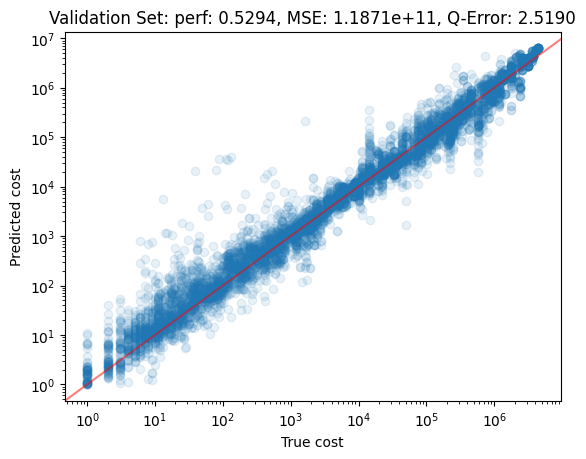

In [46]:
# Evaluation
best_model.eval()

data = next(iter(DataLoader(val_dataset, batch_size=6000, shuffle=True))).to(device)
y = torch.exp(best_model(data.x, data.edge_index, batch=data.batch))
x = data.y

perf, mse_metric, qerror_metric = validate_model(best_model, criterion, val_loader, device, loss_type=loss_type)

fig, ax = plt.subplots()
ax.scatter(x.cpu().detach().numpy(), y.cpu().detach().numpy(), alpha=0.1)
ax.axline((0, 0), slope=1, color="red", alpha=0.5, zorder=1)
ax.set_xlabel("True cost")
ax.set_ylabel("Predicted cost")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title(f"Validation Set: perf: {perf:.4f}, MSE: {mse_metric:.4e}, Q-Error: {qerror_metric:.4f}")
plt.show()

In [58]:
# Loading unbalanced dataset
import pickle

with open("./datasets/lubm/example_star_dataset_compact_implicit_join.pkl", "rb") as f:
	_, unbalanced_dataset = zip(*pickle.load(f))

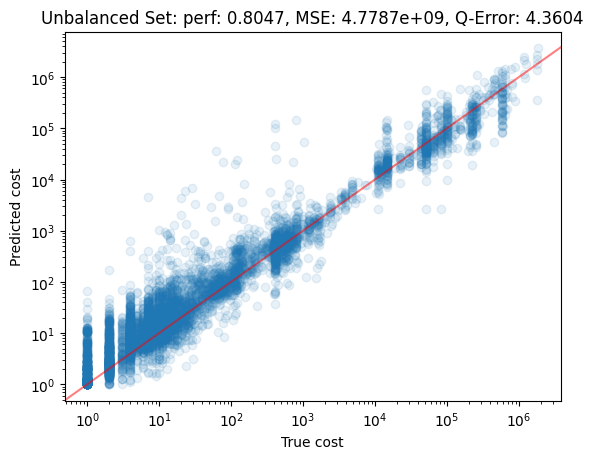

In [60]:
# Evaluation
best_model.eval()

data = next(iter(DataLoader(unbalanced_dataset, batch_size=6000, shuffle=True))).to(device)
y = torch.exp(best_model(data.x, data.edge_index, batch=data.batch))
x = data.y

perf, mse_metric, qerror_metric = validate_model(best_model, criterion, DataLoader(unbalanced_dataset, batch_size=6000), device, loss_type=loss_type)

fig, ax = plt.subplots()
ax.scatter(x.cpu().detach().numpy(), y.cpu().detach().numpy(), alpha=0.1)
ax.axline((0, 0), slope=1, color="red", alpha=0.5, zorder=1)
ax.set_xlabel("True cost")
ax.set_ylabel("Predicted cost")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title(f"Unbalanced Set: perf: {perf:.4f}, MSE: {mse_metric:.4e}, Q-Error: {qerror_metric:.4f}")
plt.show()

In [62]:
torch.save(best_model, "./datasets/lubm/costgnnv2_implicit_balanced_q4.3.pkl")